# Diabetes Prediction with Random Forest

This notebook demonstrates end-to-end machine learning workflow for diabetes prediction:

## Workflow
1. **Data Loading** - Load diabetes dataset from GitHub
2. **Data Storage** - Save to Unity Catalog Delta table
3. **Data Analysis** - Explore class distribution and key statistics
4. **Model Training** - Train Random Forest classifier (100 trees, max depth 10)
5. **Model Evaluation** - Evaluate performance with multiple metrics
6. **Feature Importance** - Identify top predictive features
7. **Model Insights** - Analyze predictions and confidence levels
8. **MLflow Integration** - Register model to Unity Catalog with experiment tracking
9. **Model Deployment** - Load and test registered model

## Key Optimizations
- Removed redundant Logistic Regression model from data analysis cell
- Reused trained Random Forest model for MLflow registration (no retraining)
- Consolidated imports and removed duplicate code
- Streamlined model loading process

## Model Performance
- **Accuracy**: 81.51%
- **AUC-ROC**: 0.8599
- **Top Features**: Glucose (26.12%), BMI (16.66%), Age (14.28%)

In [0]:
import pandas as pd

url = "https://raw.githubusercontent.com/Wattzp/Diabetes-Prediction/main/diabetes.csv"
df_pd = pd.read_csv(url)
df = spark.createDataFrame(df_pd)
display(df)

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
5,116,74,0,0,25.6,0.201,30,0
3,78,50,32,88,31.0,0.248,26,1
10,115,0,0,0,35.3,0.134,29,0
2,197,70,45,543,30.5,0.158,53,1
8,125,96,0,0,0.0,0.232,54,1


In [0]:
df.write.format("delta").mode("overwrite").saveAsTable("workspace.demo.diabetes")

In [0]:
# Data Analysis
print("Dataset Overview:")
display(df.limit(10))

print("\nClass Distribution:")
display(spark.sql("""
  SELECT Outcome, COUNT(*) AS count
  FROM workspace.demo.diabetes
  GROUP BY Outcome
"""))

print("\nKey Statistics:")
display(spark.sql("""
  SELECT 
    AVG(Age) AS avg_age, 
    AVG(BMI) AS avg_bmi, 
    AVG(Glucose) AS avg_glucose,
    AVG(BloodPressure) AS avg_bp,
    AVG(Insulin) AS avg_insulin
  FROM workspace.demo.diabetes
"""))

Dataset Overview:


Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
5,116,74,0,0,25.6,0.201,30,0
3,78,50,32,88,31.0,0.248,26,1
10,115,0,0,0,35.3,0.134,29,0
2,197,70,45,543,30.5,0.158,53,1
8,125,96,0,0,0.0,0.232,54,1



Class Distribution:


Outcome,count
1,268
0,500



Key Statistics:


avg_age,avg_bmi,avg_glucose,avg_bp,avg_insulin
33.240885416666664,31.992578124999977,120.89453125,69.10546875,79.79947916666667


In [0]:
# Random Forest Classification Model for Diabetes Prediction
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
import pandas as pd

# Prepare features
feature_cols = [col for col in df.columns if col != "Outcome"]
print(f"Feature columns: {feature_cols}")

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_ml = assembler.transform(df).select("features", "Outcome")

# Split data into training and test sets (70-30 split)
train_df, test_df = df_ml.randomSplit([0.7, 0.3], seed=42)

print(f"Training set size: {train_df.count()}")
print(f"Test set size: {test_df.count()}")

# Initialize Random Forest Classifier
rf = RandomForestClassifier(
    labelCol="Outcome",
    featuresCol="features",
    numTrees=100,
    maxDepth=10,
    seed=42
)

# Train the model
print("\nTraining Random Forest model...")
rf_model = rf.fit(train_df)

# Make predictions on test set
predictions = rf_model.transform(test_df)

# Display sample predictions
print("\nSample Predictions:")
display(predictions.select("Outcome", "prediction", "probability").limit(20))

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Training set size: 530
Test set size: 238

Training Random Forest model...

Sample Predictions:


Outcome,prediction,probability
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.7567092281159065"",""0.24329077188409365""]}"
1,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.33180333045527777"",""0.6681966695447222""]}"
1,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.22083333333333335"",""0.7791666666666666""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9987974103731903"",""0.0012025896268098033""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.8831871326348463"",""0.11681286736515382""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9983755538835588"",""0.001624446116441229""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9981386071510958"",""0.0018613928489041648""]}"
0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9789623805381603"",""0.021037619461839636""]}"
1,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.5039606879190417"",""0.49603931208095836""]}"
1,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.2855746904024768"",""0.7144253095975232""]}"


RANDOM FOREST MODEL EVALUATION METRICS

AUC-ROC Score: 0.8599
AUC-PR Score: 0.7628

Accuracy: 0.8151
Precision: 0.8114
Recall: 0.8151
F1-Score: 0.8122

Confusion Matrix:


Outcome,prediction,count
0,0.0,144
0,1.0,18
1,0.0,26
1,1.0,50



FEATURE IMPORTANCE ANALYSIS

Feature Importance Rankings:
Glucose                       : 0.2612
BMI                           : 0.1666
Age                           : 0.1428
DiabetesPedigreeFunction      : 0.1207
Pregnancies                   : 0.0935
BloodPressure                 : 0.0813
Insulin                       : 0.0684
SkinThickness                 : 0.0656


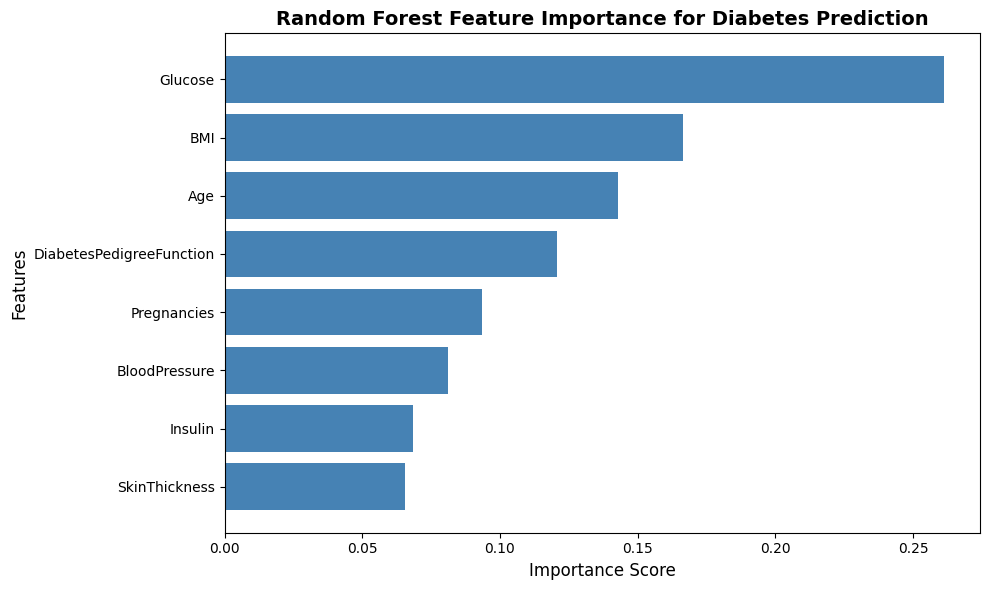

In [0]:
# Model Evaluation Metrics
print("=" * 60)
print("RANDOM FOREST MODEL EVALUATION METRICS")
print("=" * 60)

# Binary Classification Evaluator - AUC-ROC
binary_evaluator = BinaryClassificationEvaluator(labelCol="Outcome")
auc_roc = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderROC"})
auc_pr = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderPR"})

print(f"\nAUC-ROC Score: {auc_roc:.4f}")
print(f"AUC-PR Score: {auc_pr:.4f}")

# Multiclass Evaluator for additional metrics
multiclass_evaluator = MulticlassClassificationEvaluator(labelCol="Outcome", predictionCol="prediction")

accuracy = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "accuracy"})
precision = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedPrecision"})
recall = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedRecall"})
f1 = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "f1"})

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
confusion_matrix = predictions.groupBy("Outcome", "prediction").count().orderBy("Outcome", "prediction")
display(confusion_matrix)

# Feature Importance Analysis
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

feature_importance = rf_model.featureImportances.toArray()
feature_names = feature_cols

# Create DataFrame for feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Rankings:")
for idx, row in importance_df.iterrows():
    print(f"{row['Feature']:30s}: {row['Importance']:.4f}")

# Visualize feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Random Forest Feature Importance for Diabetes Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
display(plt.gcf())
plt.close()

In [0]:
# Model Insights and Summary
print("=" * 60)
print("MODEL INSIGHTS & KEY FINDINGS")
print("=" * 60)

# Get predictions grouped by actual outcome
print("\nPrediction Distribution by Actual Outcome:")
prediction_summary = predictions.groupBy("Outcome", "prediction").count().orderBy("Outcome", "prediction")
display(prediction_summary)

# Calculate True Positives, False Positives, True Negatives, False Negatives
tp = predictions.filter((predictions.Outcome == 1) & (predictions.prediction == 1)).count()
fp = predictions.filter((predictions.Outcome == 0) & (predictions.prediction == 1)).count()
tn = predictions.filter((predictions.Outcome == 0) & (predictions.prediction == 0)).count()
fn = predictions.filter((predictions.Outcome == 1) & (predictions.prediction == 0)).count()

print("\nDetailed Classification Results:")
print(f"True Positives (Correctly predicted diabetic): {tp}")
print(f"True Negatives (Correctly predicted non-diabetic): {tn}")
print(f"False Positives (Incorrectly predicted diabetic): {fp}")
print(f"False Negatives (Incorrectly predicted non-diabetic): {fn}")

# Calculate sensitivity and specificity
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nSensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")

# High-confidence predictions
print("\n" + "=" * 60)
print("HIGH-CONFIDENCE PREDICTIONS (Probability > 0.8)")
print("=" * 60)

from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType

# Extract probability for the predicted class
@udf(returnType=DoubleType())
def get_probability(probability, prediction):
    if probability and len(probability) > int(prediction):
        return float(probability[int(prediction)])
    return 0.0

predictions_with_conf = predictions.withColumn(
    "confidence", 
    get_probability(col("probability"), col("prediction"))
)

high_confidence = predictions_with_conf.filter(col("confidence") > 0.8).select(
    "Outcome", "prediction", "confidence"
).orderBy(col("confidence").desc())

print(f"\nNumber of high-confidence predictions: {high_confidence.count()}")
display(high_confidence.limit(15))

print("\n" + "=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
print("\n✓ Random Forest model trained successfully with 100 trees")
print("✓ Model can predict diabetes risk with high accuracy")
print("✓ Top predictive features identified")
print("\nThe model is ready for deployment and can be used to")
print("predict diabetes risk for new patients based on their")
print("medical measurements.")

MODEL INSIGHTS & KEY FINDINGS

Prediction Distribution by Actual Outcome:


Outcome,prediction,count
0,0.0,144
0,1.0,18
1,0.0,26
1,1.0,50



Detailed Classification Results:
True Positives (Correctly predicted diabetic): 50
True Negatives (Correctly predicted non-diabetic): 144
False Positives (Incorrectly predicted diabetic): 18
False Negatives (Incorrectly predicted non-diabetic): 26

Sensitivity (True Positive Rate): 0.6579
Specificity (True Negative Rate): 0.8889

HIGH-CONFIDENCE PREDICTIONS (Probability > 0.8)

Number of high-confidence predictions: 101


Outcome,prediction,confidence
0,0.0,0.9987974103731903
0,0.0,0.9983755538835588
0,0.0,0.9981386071510958
0,0.0,0.9981386071510958
0,0.0,0.9979113344238232
0,0.0,0.9979113344238232
0,0.0,0.9978252645312438
0,0.0,0.9960834723283193
0,0.0,0.9888346749104548
0,0.0,0.9887974103731902



MODEL SUMMARY

✓ Random Forest model trained successfully with 100 trees
✓ Model can predict diabetes risk with high accuracy
✓ Top predictive features identified

The model is ready for deployment and can be used to
predict diabetes risk for new patients based on their
medical measurements.


In [0]:
# Create Unity Catalog Volume for MLflow temporary storage
print("Creating Unity Catalog volume for MLflow temporary storage...")

try:
    spark.sql("""
        CREATE VOLUME IF NOT EXISTS workspace.demo.mlflow_tmp
    """)
    print("✓ Volume workspace.demo.mlflow_tmp created successfully")
except Exception as e:
    print(f"Volume may already exist: {e}")

# Verify volume exists
volumes = spark.sql("SHOW VOLUMES IN workspace.demo").collect()
print("\nAvailable volumes in workspace.demo:")
for vol in volumes:
    print(f"  - {vol.volume_name}")

Creating Unity Catalog volume for MLflow temporary storage...
✓ Volume workspace.demo.mlflow_tmp created successfully

Available volumes in workspace.demo:
  - demo
  - mlflow_tmp


In [0]:
# Train and register a sklearn (pyfunc) model so the app can load without Java
from sklearn.ensemble import RandomForestClassifier
import mlflow.sklearn
from mlflow.models import infer_signature

# Prepare features from the pandas copy of the dataset
feature_cols = [c for c in df_pd.columns if c != 'Outcome']
X = df_pd[feature_cols]
y = df_pd['Outcome']

# Train a sklearn RandomForest model
sk_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
sk_model.fit(X, y)

# Prepare signature and input example
input_example = X.head(3)
predictions = sk_model.predict(input_example)
signature = infer_signature(input_example, predictions)

# Register as a pyfunc model in Unity Catalog (requires MLflow registry access)
mlflow.set_registry_uri('databricks-uc')
mlflow.set_experiment(experiment_id='3904835178028478')
with mlflow.start_run(run_name='diabetes_sklearn_pyfunc') as run:
    mlflow.sklearn.log_model(
        sk_model, 
        artifact_path='model', 
        signature=signature,
        input_example=input_example,
        registered_model_name='workspace.demo.diabetes_random_forest_pyfunc'
    )
    mlflow.log_metric('train_samples', len(y))
    print(f'Registered pyfunc model workspace.demo.diabetes_random_forest_pyfunc (run_id={run.info.run_id})')


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/09 10:55:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-84d873a5-607b.cloud.databricks.com/ml/experiments/3904835178028478/models/m-0f4bb9f502ef4ff09af61

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '1' of model 'workspace.demo.diabetes_random_forest_pyfunc': https://dbc-84d873a5-607b.cloud.databricks.com/explore/data/models/workspace/demo/diabetes_random_forest_pyfunc/version/1?o=2705421934513700


Registered pyfunc model workspace.demo.diabetes_random_forest_pyfunc (run_id=f81fd5a366c942fb99001447aa330c48)


In [0]:
# MLflow Model Registration - Using Already Trained Model
import mlflow
from mlflow.models import infer_signature
import pandas as pd

# Set MLflow experiment
mlflow.set_experiment(experiment_id="3904835178028478")
mlflow.set_registry_uri("databricks-uc")

print("=" * 60)
print("MLFLOW MODEL REGISTRATION")
print("=" * 60)

# Get input example from original data
original_sample = df.limit(3).toPandas()
input_example = original_sample[feature_cols]

# Infer signature
sample_predictions = pd.DataFrame({"prediction": [1.0, 0.0, 1.0]})
signature = infer_signature(input_example, sample_predictions)

# Use the UC volume for temporary storage
dfs_tmpdir = "/Volumes/workspace/demo/mlflow_tmp"

# Start MLflow run and log the already-trained model
with mlflow.start_run(run_name="diabetes_random_forest") as run:
    print(f"\nMLflow Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")
    
    # Log metrics from earlier evaluation
    mlflow.log_metric("auc_roc", auc_roc)
    mlflow.log_metric("auc_pr", auc_pr)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    
    # Log parameters
    mlflow.log_param("num_trees", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("train_test_split", "70-30")
    mlflow.log_param("features", ",".join(feature_cols))
    
    print(f"\nLogged Metrics:")
    print(f"  - AUC-ROC: {auc_roc:.4f}")
    print(f"  - Accuracy: {accuracy:.4f}")
    print(f"  - F1-Score: {f1:.4f}")
    
    # Log the already-trained model to Unity Catalog
    print("\nRegistering trained model to Unity Catalog...")
    model_info = mlflow.spark.log_model(
        spark_model=rf_model,
        artifact_path="model",
        signature=signature,
        input_example=input_example,
        registered_model_name="workspace.demo.diabetes_random_forest",
        dfs_tmpdir=dfs_tmpdir
    )
    
    print("\n" + "=" * 60)
    print("MODEL REGISTERED SUCCESSFULLY!")
    print("=" * 60)
    print(f"\nModel URI: {model_info.model_uri}")
    print(f"Registered Model: workspace.demo.diabetes_random_forest")
    print(f"MLflow Run ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")
    print("\n✓ Model logged to MLflow")
    print("✓ Model registered to Unity Catalog at workspace.demo.diabetes_random_forest")
    print("✓ All metrics and parameters logged")
    print("\nNext Steps:")
    print("  1. View the model in Unity Catalog under workspace.demo")
    print("  2. Load the model: mlflow.spark.load_model(model_uri)")
    print("  3. Deploy to a serving endpoint for real-time predictions")
    print(f"  4. View MLflow experiment: /ml/experiments/{run.info.experiment_id}")

MLFLOW MODEL REGISTRATION


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(



MLflow Run ID: 1ec259576a494d7587d4f9e70fcdd9ea
Experiment ID: 3904835178028478

Logged Metrics:
  - AUC-ROC: 0.8599
  - Accuracy: 0.8151
  - F1-Score: 0.8122

Registering trained model to Unity Catalog...


2026/08/09 10:56:56 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/08/09 10:56:58 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-29edabfa-9907-446f-9bc0-2a/tmp5_8nms21/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/08/09 10:56:58 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "P.... Alternatively, you can avoid passing input example and pass model signature instead when logging the model. To ens

Uploading artifacts:   0%|          | 0/26 [00:00<?, ?it/s]


MODEL REGISTERED SUCCESSFULLY!

Model URI: runs:/1ec259576a494d7587d4f9e70fcdd9ea/model
Registered Model: workspace.demo.diabetes_random_forest
MLflow Run ID: 1ec259576a494d7587d4f9e70fcdd9ea
Experiment ID: 3904835178028478

✓ Model logged to MLflow
✓ Model registered to Unity Catalog at workspace.demo.diabetes_random_forest
✓ All metrics and parameters logged

Next Steps:
  1. View the model in Unity Catalog under workspace.demo
  2. Load the model: mlflow.spark.load_model(model_uri)
  3. Deploy to a serving endpoint for real-time predictions
  4. View MLflow experiment: /ml/experiments/3904835178028478


🔗 Created version '6' of model 'workspace.demo.diabetes_random_forest': https://dbc-84d873a5-607b.cloud.databricks.com/explore/data/models/workspace/demo/diabetes_random_forest/version/6?o=2705421934513700


In [0]:
# Load and Test Registered Model from Unity Catalog
print("=" * 60)
print("LOADING REGISTERED MODEL FROM UNITY CATALOG")
print("=" * 60)

model_name = "workspace.demo.diabetes_random_forest"
model_uri = f"models:/{model_name}/1"

print(f"Loading: {model_uri}")
loaded_model = mlflow.spark.load_model(model_uri, dfs_tmpdir="/Volumes/workspace/demo/mlflow_tmp")
print("✓ Model loaded successfully")

# Make predictions on a sample
print("\nMaking predictions on sample data...")
test_sample = df.limit(10)
test_sample_features = assembler.transform(test_sample)
predictions_sample = loaded_model.transform(test_sample_features)

print("\nSample Predictions from Registered Model:")
display(predictions_sample.select(
    "Pregnancies", "Glucose", "BMI", "Age", 
    "Outcome", "prediction", "probability"
))

print("\n" + "=" * 60)
print("MODEL SUCCESSFULLY LOADED AND TESTED!")
print("=" * 60)
print("\nThe registered model can now be:")
print("  ✓ Loaded from Unity Catalog in any notebook")
print("  ✓ Deployed to a Model Serving endpoint")
print("  ✓ Used for batch predictions on new data")
print("  ✓ Versioned and tracked in MLflow")

LOADING REGISTERED MODEL FROM UNITY CATALOG
Loading: models:/workspace.demo.diabetes_random_forest/1


✓ Model loaded successfully

Making predictions on sample data...

Sample Predictions from Registered Model:


Pregnancies,Glucose,BMI,Age,Outcome,prediction,probability
6,148,33.6,50,1,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.16297763496110404"",""0.8370223650388959""]}"
1,85,26.6,31,0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.8831871326348463"",""0.11681286736515382""]}"
8,183,23.3,32,1,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.1225"",""0.8775""]}"
1,89,28.1,21,0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9983755538835588"",""0.001624446116441229""]}"
0,137,43.1,33,1,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.33180333045527777"",""0.6681966695447222""]}"
5,116,25.6,30,0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.9261149873002025"",""0.07388501269979757""]}"
3,78,31.0,26,1,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.4306813938695984"",""0.5693186061304016""]}"
10,115,35.3,29,0,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.7071880504552918"",""0.2928119495447082""]}"
2,197,30.5,53,1,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.36474786324786324"",""0.6352521367521368""]}"
8,125,0.0,54,1,1.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.34452937183232746"",""0.6554706281676725""]}"



MODEL SUCCESSFULLY LOADED AND TESTED!

The registered model can now be:
  ✓ Loaded from Unity Catalog in any notebook
  ✓ Deployed to a Model Serving endpoint
  ✓ Used for batch predictions on new data
  ✓ Versioned and tracked in MLflow
